In [1905]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

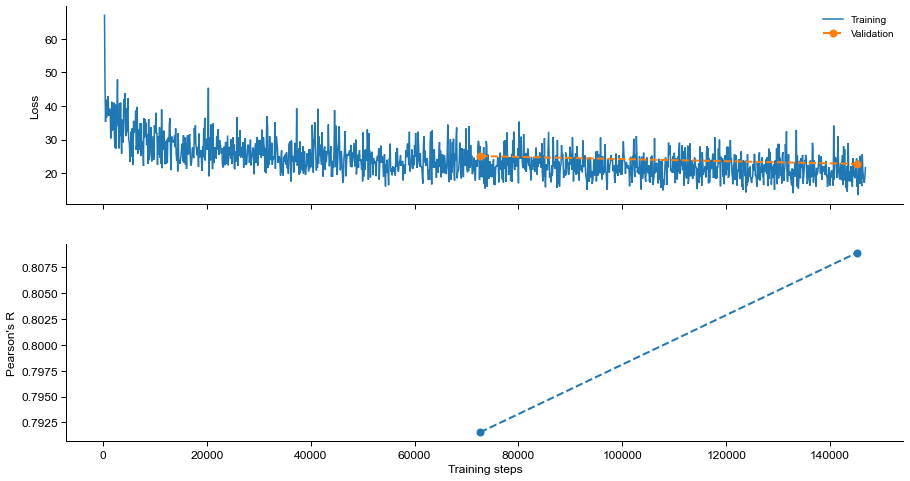

In [2295]:
metrics = pd.read_csv(
    "models/data_AUG3/logs/lightning_logs/version_0/metrics.csv"
)

i = metrics.loss.abs() > 100
metrics.loc[i, "loss"] = pd.NA

val_steps = ~metrics.val_loss.isna()
val_metrics = metrics[val_steps]
train_metrics = metrics[~val_steps]

fig, ax = plt.subplots(2, 1, sharex=True)

i = ~np.isnan(metrics.loss)
ax[0].plot(metrics.step[i], metrics.loss[i], label="Training")
ax[0].plot(
    val_metrics.step, val_metrics.val_loss, "o--", lw=2, ms=8, label="Validation"
)
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(val_metrics.step, val_metrics.val_pcc, "o--", lw=2, ms=8, label="Validation")
ax[1].set_xlabel("Training steps")
ax[1].set_ylabel("Pearson's R")

fig.set_size_inches(15, 8)

In [2298]:
val_metrics.sort_values(by="val_loss")

,epoch,loss,lr-AdamW,step,val_loss,val_pcc
2905,0.0,NaN,NaN,145253,22.741602,0.808928
1452,0.0,NaN,NaN,72626,25.074926,0.791552


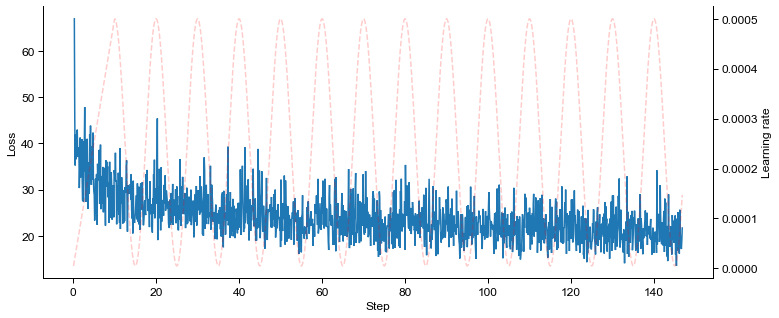

In [2297]:
fig, ax = plt.subplots()

i = ~np.isnan(metrics.loss)
ax.plot(metrics.step[i]/1000, metrics.loss[i])
ax.set_xlabel("Step")
ax.set_ylabel("Loss")


ax = ax.twinx()
i = ~np.isnan(metrics["lr-AdamW"])
ax.plot(metrics.step[i]/1000, metrics["lr-AdamW"][i], color="red", ls="--", alpha=0.2)

ax.set_ylabel("Learning rate")

ax.spines["right"].set_visible(True)

fig.set_size_inches(12, 5)